Goal here is to see how we might do multigrid interp between levels for an isogeometric B-spline basis.
The tricky part is that the mid-side nodes are not exactly a node point.
Also in middle of plate, corner nodes of element are also not lagrange-lobatto-like and don't line up with node.
Is that right? Let's see by comparing basis functions between levels in 1D (maybe some simple non-PDE function with multigrid).

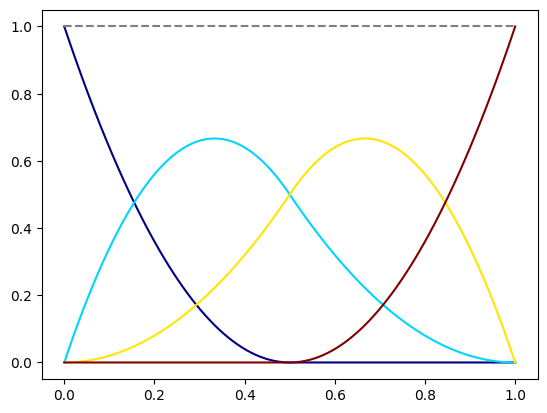

In [2]:
# first run with nxe = 2 elements (then we'll do four)
import matplotlib.pyplot as plt
import numpy as np

nxe, p = 2, 2
# nxe, p = 16, 2
nglob = nxe+p # number of global basis functions
colors = plt.cm.jet(np.linspace(0.0, 1.0, nglob))
knots = [0.0]*(p+1) + [i/nxe for i in range(1,nxe)] + [1.0]*(p+1)
def quad_bernstein(xi):
    N = np.array([(1-xi)**2, 2*xi*(1-xi), xi**2])
    dN = np.array([-2*(1-xi), 2*(1-2*xi), 2*xi])
    return N, dN
u = np.linspace(0.0, 1.0, 100)
global_basis = np.zeros((nglob, u.shape[0]))
elem_conn = [
    [i, i+1, i+2] for i in range(nxe) # element connectivity
]
for ielem in range(nxe):
# for ielem in range(1):
    knot1, knot2 = knots[p+ielem], knots[p+ielem+1]
    # compute normalized coordinates in here
    xi = (u - knot1) / (knot2 - knot1)
    # zero out using mask products if xi not in 0, 1
    xi_mask = np.logical_and(xi >= 0.0, xi <= 1.0)
    # compute bernstein coefficients
    B, dB = quad_bernstein(xi)

    left_bndry = abs(knots[p+ielem-1] - knot1) < 1e-12
    right_bndry = abs(knots[p+ielem+2] - knot2) < 1e-12

    # define optional BtoN coeffs based on el;ement position
    # on GPU can simply use the element index (or maybe max or min bndry stuff, or just check repeated knots on one side?)
    N1_B0 = 0.0 if left_bndry else 0.5
    N2_B0 = 1.0 if left_bndry else 0.5
    N1_B2 = 0.0 if right_bndry else 0.5
    N0_B2 = 1.0 if right_bndry else 0.5

    N0 = N2_B0 * B[0]
    N1 = N1_B0 * B[0] + B[1] + N1_B2 * B[2]
    N2 = N0_B2 * B[2]

    # now add into these basis functions if they exist
    local_conn = elem_conn[ielem]
    g0, g1, g2 = local_conn[0], local_conn[1], local_conn[2]
    global_basis[g0] += N0 * xi_mask
    global_basis[g1] += N1 * xi_mask
    global_basis[g2] += N2 * xi_mask

# now plot each global basis function
for iglob in range(nglob):
    plt.plot(u, global_basis[iglob], color=colors[iglob])

# and check the sum of each basis functions
SUM = np.sum(global_basis, axis=0)
plt.plot(u, SUM, '--', color="tab:gray")
# sum is 1!
plt.show()

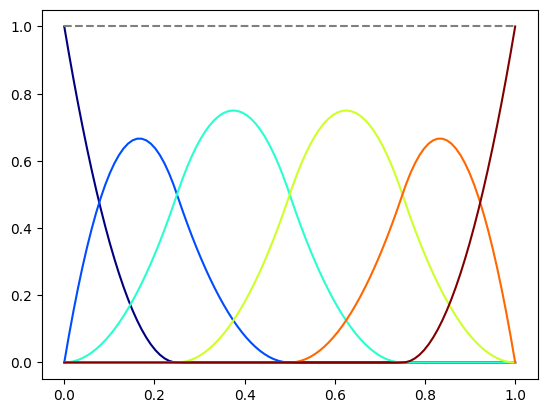

In [3]:
# then nxe = 4 elems

nxe, p = 4, 2
# nxe, p = 16, 2
nglob = nxe+p # number of global basis functions
colors = plt.cm.jet(np.linspace(0.0, 1.0, nglob))
knots = [0.0]*(p+1) + [i/nxe for i in range(1,nxe)] + [1.0]*(p+1)
def quad_bernstein(xi):
    N = np.array([(1-xi)**2, 2*xi*(1-xi), xi**2])
    dN = np.array([-2*(1-xi), 2*(1-2*xi), 2*xi])
    return N, dN
u = np.linspace(0.0, 1.0, 100)
global_basis = np.zeros((nglob, u.shape[0]))
elem_conn = [
    [i, i+1, i+2] for i in range(nxe) # element connectivity
]
for ielem in range(nxe):
# for ielem in range(1):
    knot1, knot2 = knots[p+ielem], knots[p+ielem+1]
    # compute normalized coordinates in here
    xi = (u - knot1) / (knot2 - knot1)
    # zero out using mask products if xi not in 0, 1
    xi_mask = np.logical_and(xi >= 0.0, xi <= 1.0)
    # compute bernstein coefficients
    B, dB = quad_bernstein(xi)

    left_bndry = abs(knots[p+ielem-1] - knot1) < 1e-12
    right_bndry = abs(knots[p+ielem+2] - knot2) < 1e-12

    # define optional BtoN coeffs based on el;ement position
    # on GPU can simply use the element index (or maybe max or min bndry stuff, or just check repeated knots on one side?)
    N1_B0 = 0.0 if left_bndry else 0.5
    N2_B0 = 1.0 if left_bndry else 0.5
    N1_B2 = 0.0 if right_bndry else 0.5
    N0_B2 = 1.0 if right_bndry else 0.5

    N0 = N2_B0 * B[0]
    N1 = N1_B0 * B[0] + B[1] + N1_B2 * B[2]
    N2 = N0_B2 * B[2]

    # now add into these basis functions if they exist
    local_conn = elem_conn[ielem]
    g0, g1, g2 = local_conn[0], local_conn[1], local_conn[2]
    global_basis[g0] += N0 * xi_mask
    global_basis[g1] += N1 * xi_mask
    global_basis[g2] += N2 * xi_mask

# now plot each global basis function
for iglob in range(nglob):
    plt.plot(u, global_basis[iglob], color=colors[iglob])

# and check the sum of each basis functions
SUM = np.sum(global_basis, axis=0)
plt.plot(u, SUM, '--', color="tab:gray")
# sum is 1!
plt.show()

P_dof=array([[0.75, 0.25, 0.  ],
       [0.25, 0.75, 0.75],
       [0.  , 0.  , 0.25]])


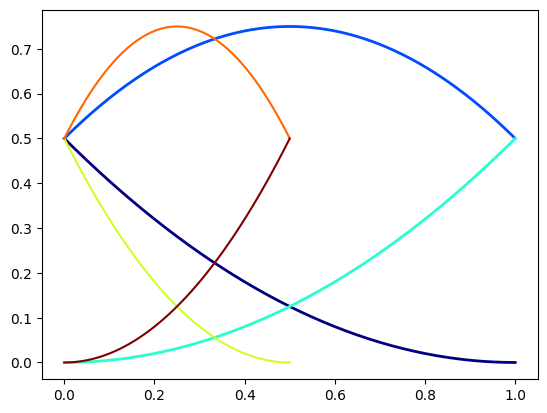

In [ ]:
# basically need to do a local projection mapping from fine to coarse bases of KNOT INSERTION of b-spline basis
# may be even more accurate multigrid prolongation than standard lagrange bases..
# this is because prolongation is a geometric-style operator and high-order lagrange is not as great at smoothly modeling geometry..

# so in other words this could give MUCH BETTER MULTIGRID PERFORMANCE TOO (with high order) - cool!

# need to solve the basis functions coefficient interps at polynomial level (depending on interior vs bndry), etc.
# e.g. need to consider the 1st fine basis function spans half the coarse elem and we need it to be interpolated from 
# the three coarse basis functions (by solving 3x3 system, pre-computed and then we'll just assemble those coefficients)

xi = np.linspace(0.0, 1.0, 201)
N_H = np.array([0.5 - xi + xi**2/2.0, 0.5 + xi - xi**2, xi**2/2.0])
# plot the coarse basis functions for an interior element
for i in range(3):
    plt.plot(xi, N_H[i], color=colors[i], linewidth=2.0)

# now compute first half-elem fine basis functions as interp from coarse basis
P_basis = np.array([
    [1.5, -0.5, 1.5],
    [-0.5, 1.5, -4.5],
    [0.0, 0.0, 4.0]
])
N_h = np.dot(P_basis, N_H)

# basis value interp is inverse matrix of this
# as coarse function is liek f_H = u_H^T N_H
# and to get f_h = u_h^T N_h we need u_h = P_basis^{-1} * u_H

# P_dof = np.linalg.inv(P_basis)
# print(f"{P_dof=}")
# after solving it we got
P_dof = np.array([
    [0.75, 0.25, 0.0],
    [0.25, 0.75, 0.75],
    [0.0, 0.0, 0.25],
])


half_mask = xi <= 0.5
for i in range(3):
# for i in range(1):
    plt.plot(xi[:101], N_h[i][:101], color=colors[i+3], linewidth=1.5)

